In [1]:
# Ismein handwritten digits hain:

# 0 1 2 3 4 5 6 7 8 9

# Goal:

# Image dekho aur predict karo ke ye digit kya hai.

# So:

# 28 × 28 image
#       ↓
#      ANN
#       ↓
# 0 ... 9

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
# MNIST dataset load karo
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


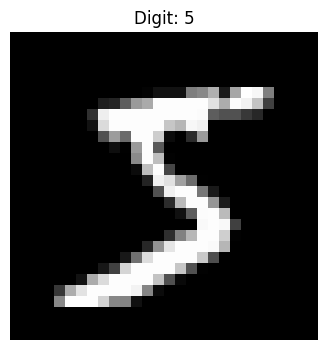

In [4]:
# lets check the iamges
plt.figure(figsize=(4, 4))

plt.imshow(X_train[0], cmap='gray')

plt.title(f"Digit: {y_train[0]}")
plt.axis('off')

plt.show()

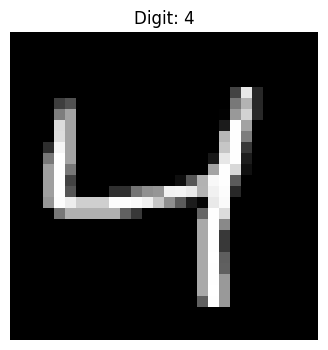

In [5]:
# lets check the iamges
plt.figure(figsize=(4, 4))

plt.imshow(X_train[2], cmap='gray')

plt.title(f"Digit: {y_train[2]}")
plt.axis('off')

plt.show()

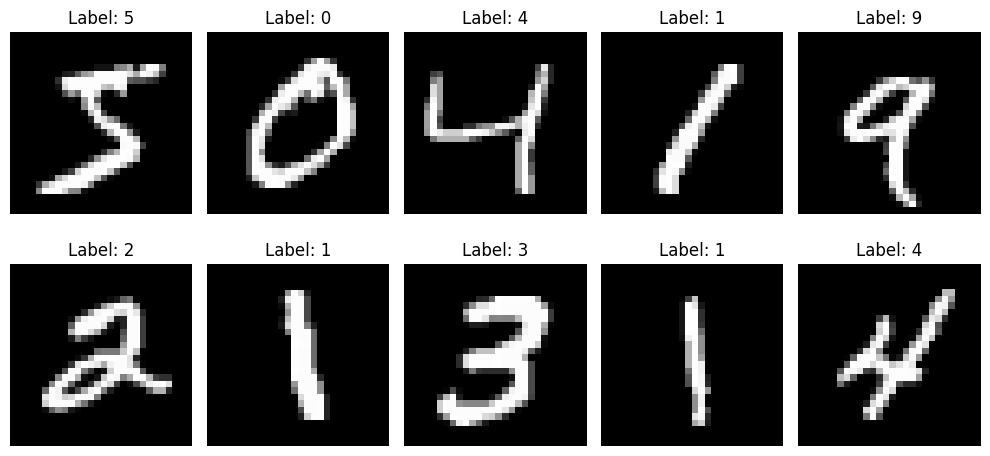

In [6]:
# multiple iamges
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Image
#  ↓
# 28 × 28 pixels
#  ↓
# 784 pixel values

In [8]:
# lets analyze one iamge
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [9]:
# ANN ko image kaise denge?

# Hamare paas:

# 28 × 28

# hai.

# Lekin normal Dense ANN ko ek flat vector dena convenient hai:

# 28 × 28 = 784

# So:

# ┌──────────────┐
# │ 28 × 28 image│
# └──────┬───────┘
#        ↓
#    Flatten
#        ↓
# 784 values
#        ↓
#      ANN

# Keras mein:

# tf.keras.layers.Flatten(input_shape=(28, 28))

# Ye:

# 28 × 28

# ko:

# 784

# mein convert karega.

In [10]:
tf.keras.layers.Flatten(input_shape=(28, 28))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<Flatten name=flatten, built=False>

In [11]:
# lets scale the values
#  0 - 255 ko 0 - 1 k bech me le ao
X_train = X_train / 255.0
X_test = X_test / 255.0

In [12]:
# ANN architecture
model = tf.keras.Sequential([

    # 28x28 image ko 784 values mein flatten karega
    tf.keras.layers.Flatten(input_shape=(28, 28)),

    # Hidden layer
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    # Output layer
    # 10 neurons because digits 0-9
    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

In [13]:
# 28 × 28 Image
#       ↓
#    Flatten
#       ↓
#    784 inputs
#       ↓
#  Dense(128)
#     ReLU
#       ↓
#  Dense(10)
#    Softmax
#       ↓
# 0 1 2 3 4 5 6 7 8 9

In [14]:
# 28 × 28 Image
#       ↓
#    Flatten
#       ↓
#    784 inputs
#       ↓
#  Dense(128)
#     ReLU
#       ↓
#  Dense(10)
#    Softmax
#       ↓
# 0 1 2 3 4 5 6 7 8 9

In [15]:
# Softmax kya karta hai?

# Softmax multiple classes ke probabilities deta hai

In [16]:
# lets compile
model.compile(

    # Weight updates
    optimizer='adam',

    # Multi-class classification
    loss='sparse_categorical_crossentropy',

    # Accuracy track karo
    metrics=['accuracy']
)

In [17]:
# lets train the network
history = model.fit(

    X_train,
    y_train,

    epochs=10,

    batch_size=32,

    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9169 - loss: 0.2893 - val_accuracy: 0.9523 - val_loss: 0.1677
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9624 - loss: 0.1283 - val_accuracy: 0.9645 - val_loss: 0.1164
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9732 - loss: 0.0885 - val_accuracy: 0.9703 - val_loss: 0.1009
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9802 - loss: 0.0647 - val_accuracy: 0.9710 - val_loss: 0.0917
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9848 - loss: 0.0498 - val_accuracy: 0.9750 - val_loss: 0.0876
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9874 - loss: 0.0391 - val_accuracy: 0.9749 - val_loss: 0.0901
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9905 - loss: 0.0307 - val_accuracy: 0.9747 - val_loss: 0.0878
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9930 - loss: 0.0231 - 

In [18]:
# Images
#   ↓
# Forward Propagation
#   ↓
# Prediction
#   ↓
# Loss
#   ↓
# Backpropagation
#   ↓
# Adam
#   ↓
# Weight Update
#   ↓
# Repeat

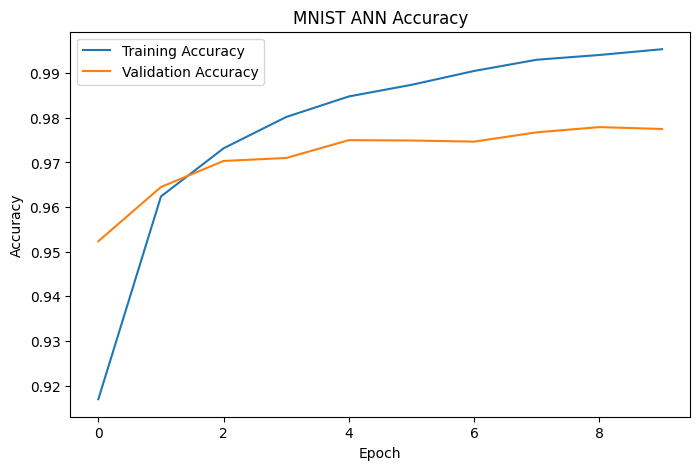

In [19]:
# accuracy graph
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MNIST ANN Accuracy")

plt.legend()
plt.show()

In [20]:
# overfit ho raha ha model


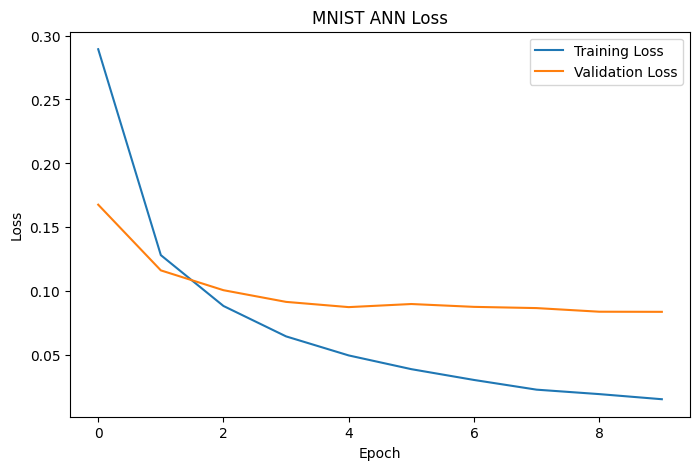

In [21]:
# loss graph
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST ANN Loss")

plt.legend()
plt.show()

In [22]:
# test performance
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9774 - loss: 0.0788
Test Loss: 0.07875188440084457
Test Accuracy: 0.977400004863739


In [23]:
# prediction
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [24]:
y_pred = y_prob.argmax(axis=1)

In [25]:
# probabilities find karo 0 - 9 tk and then jon si max ha wo le lo



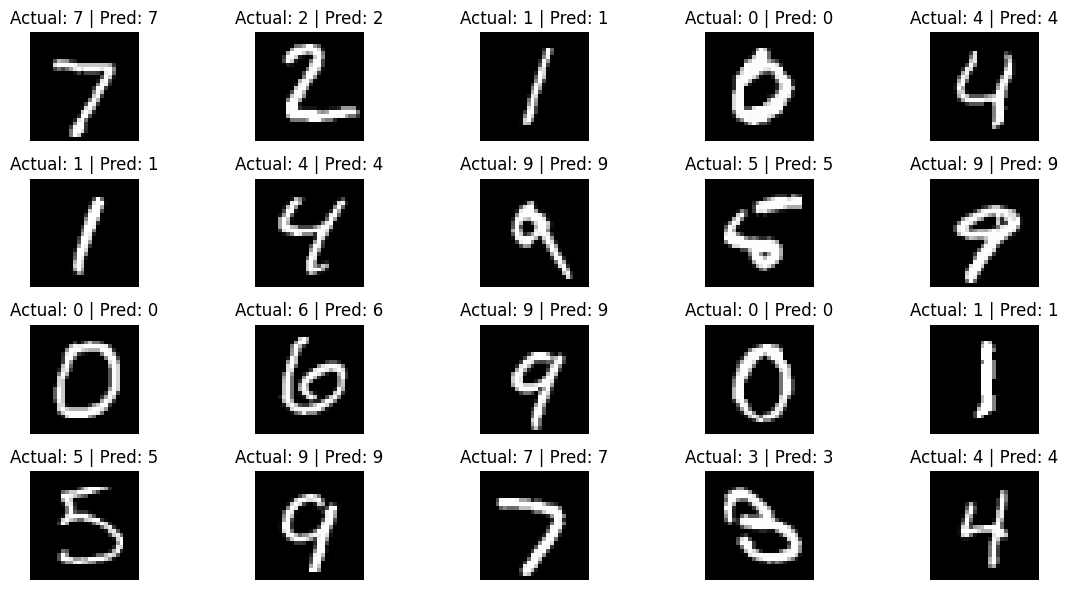

In [26]:
# actual vs predited
plt.figure(figsize=(12, 6))

for i in range(20):

    plt.subplot(4, 5, i + 1)

    plt.imshow(X_test[i], cmap='gray')

    actual = y_test[i]
    predicted = y_pred[i]

    plt.title(
        f"Actual: {actual} | Pred: {predicted}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

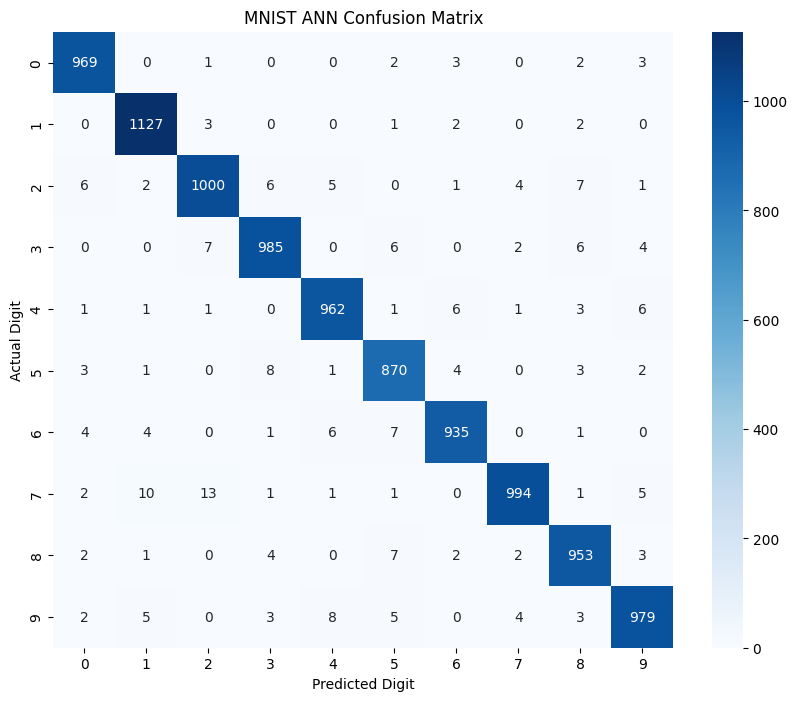

In [27]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("MNIST ANN Confusion Matrix")

plt.show()

In [29]:
# lets check wrong predictions
wrong_indices = []

for i in range(len(y_test)):

    if y_test[i] != y_pred[i]:
        wrong_indices.append(i)

print("Total wrong predictions:", len(wrong_indices))

Total wrong predictions: 226


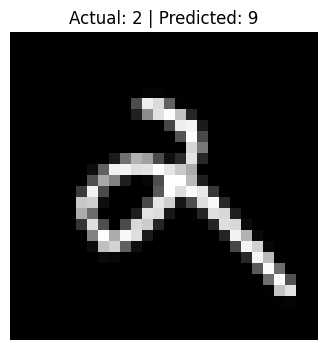

In [30]:
# first wrong prediction
i = wrong_indices[0]

plt.figure(figsize=(4, 4))

plt.imshow(X_test[i], cmap='gray')

plt.title(
    f"Actual: {y_test[i]} | Predicted: {y_pred[i]}"
)

plt.axis('off')
plt.show()